# ♬ **Predicting The Beats Per Minute Of Songs**

<p align='center'> <img src='https://i.pinimg.com/736x/09/02/d1/0902d17b40229fffdef2a6a3735fbdc6.jpg' width='50%'> </p>


Welcome to the 2025 Kaggle Playground Series! We plan to continue in the spirit of previous playgrounds, providing interesting and approachable datasets for our community to practice their machine learning skills, and anticipate a competition each month.

Your Goal: The goal of this competition is to predict a song's beats-per-minute.

Submissions are evaluated using the Root Mean Squared Error between the predicted and the observed target.

## 🧙🏽‍♂️ **1. Import libraries**

In [232]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

In [233]:
! pip install --upgrade xgboost

In [234]:
import xgboost as xgb

## 🧠 **2. Uploading datasets**

In [235]:
df_train = pd.read_csv('/content/train.csv')

In [236]:
df_test = pd.read_csv('/content/test.csv')

In [237]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB


In [238]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174722 entries, 0 to 174721
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         174722 non-null  int64  
 1   RhythmScore                174722 non-null  float64
 2   AudioLoudness              174722 non-null  float64
 3   VocalContent               174722 non-null  float64
 4   AcousticQuality            174722 non-null  float64
 5   InstrumentalScore          174722 non-null  float64
 6   LivePerformanceLikelihood  174722 non-null  float64
 7   MoodScore                  174722 non-null  float64
 8   TrackDurationMs            174722 non-null  float64
 9   Energy                     174722 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 13.3 MB


In [239]:
df_train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [240]:
df_train.describe()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,262081.500000,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,151313.257586,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.000000,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,131040.750000,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,262081.500000,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,393122.250000,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,524163.000000,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


## 🌊 **3. Data visualization. Plotting their distribution and dependence with a target value**

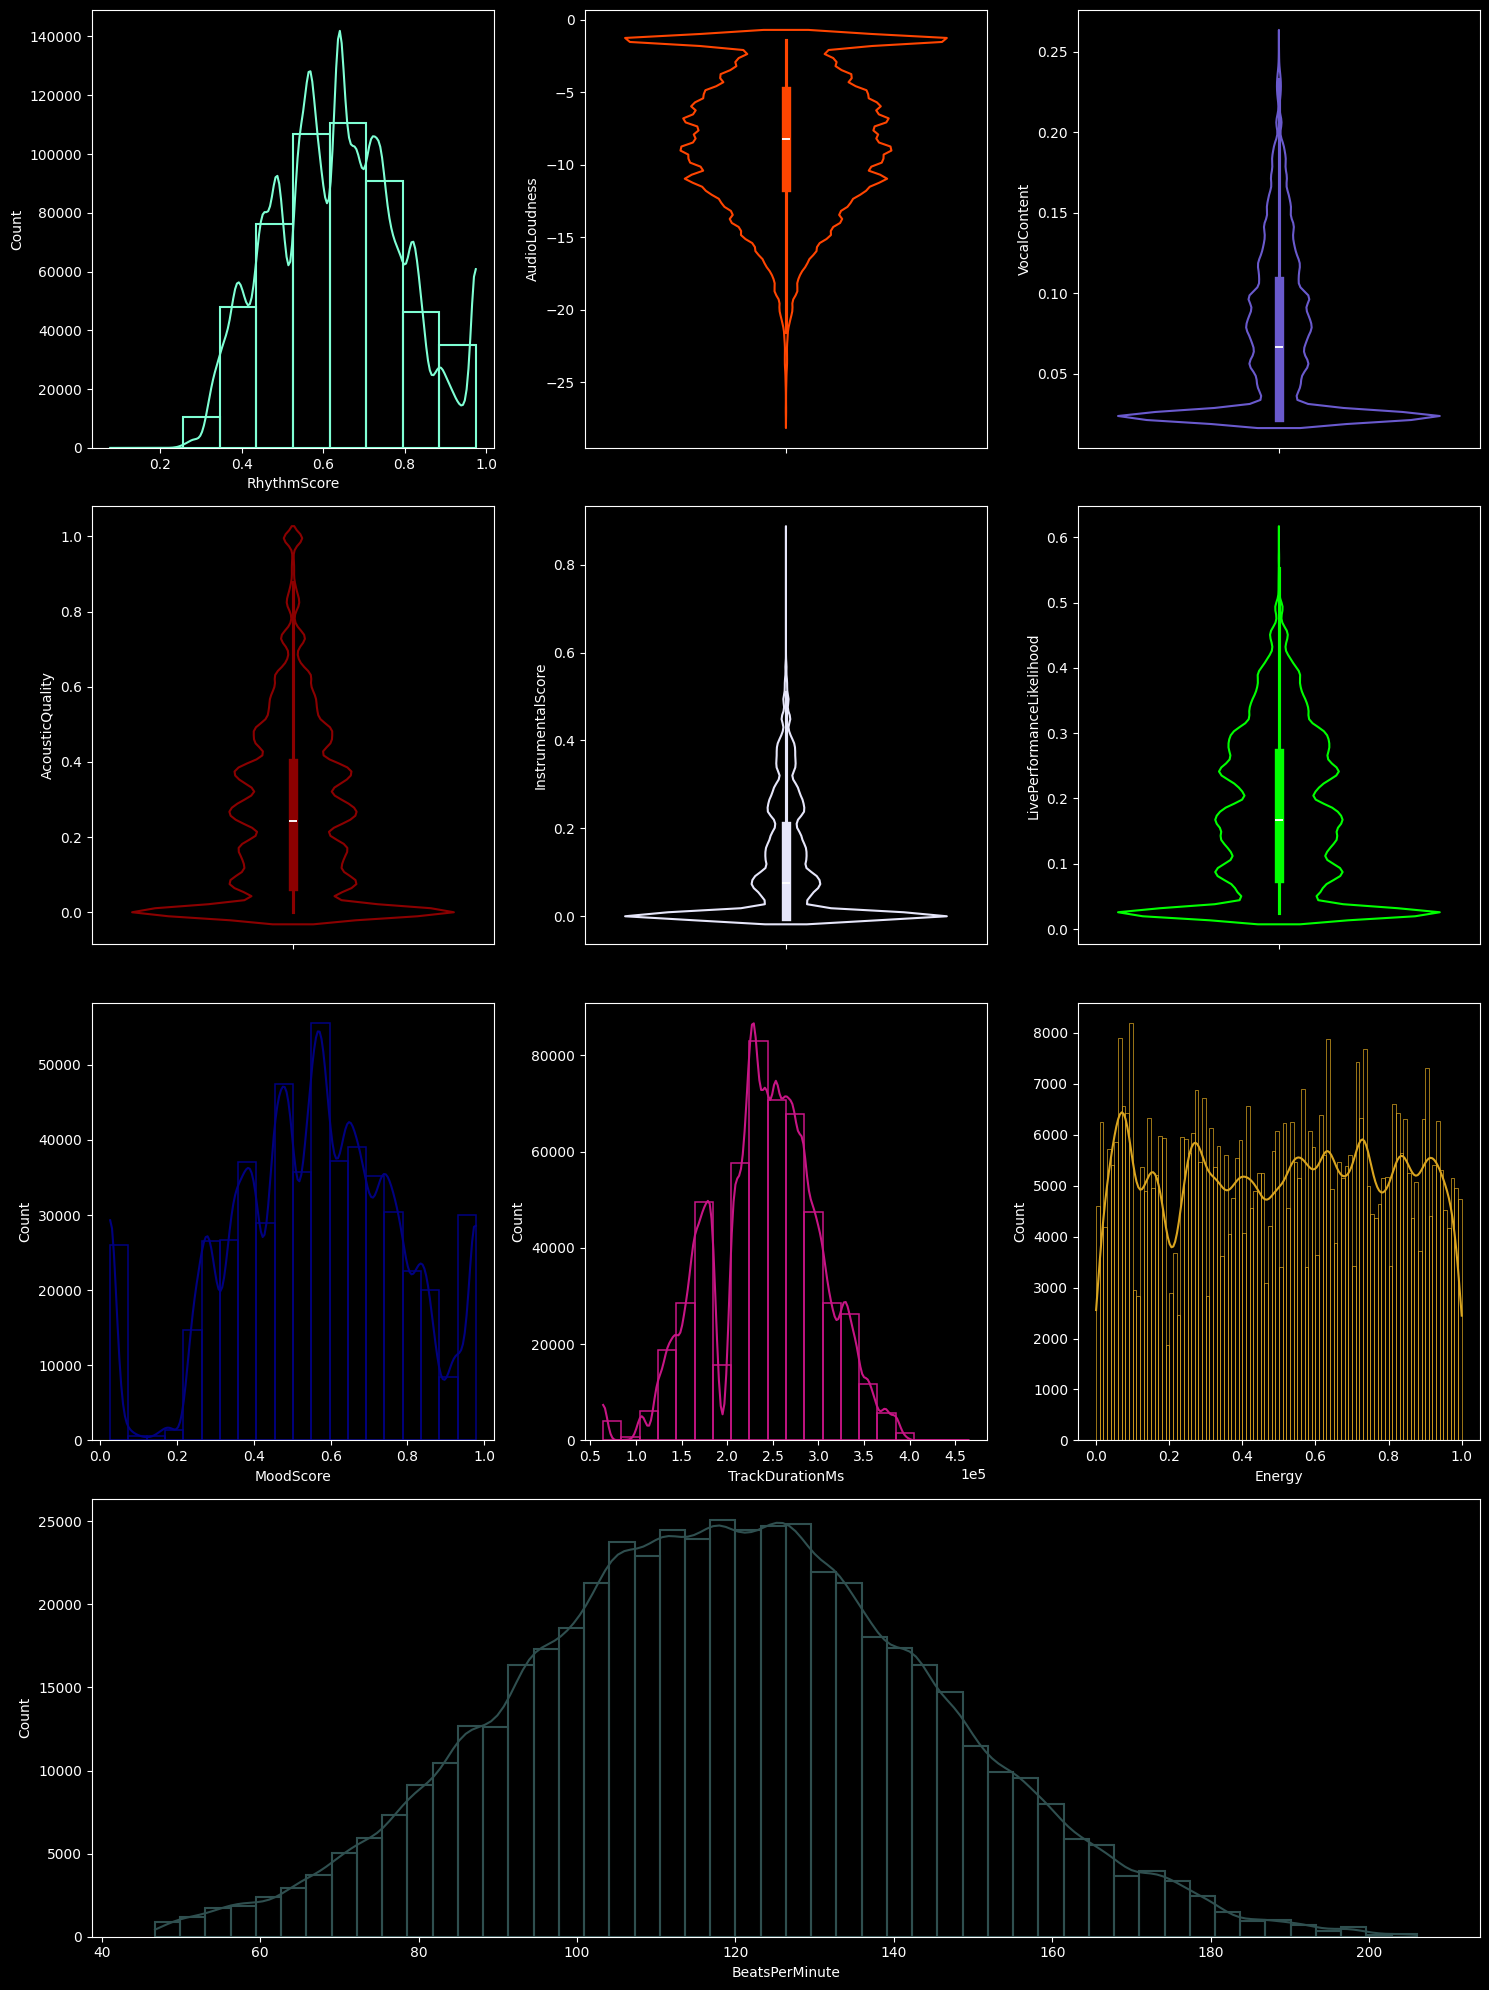

In [241]:
plt.style.use('dark_background')

figure = plt.figure(figsize = (15, 20))

grid_spec = GridSpec(nrows = 4, ncols = 3, figure = figure)

axes_1 = figure.add_subplot(grid_spec[0, 0])
sns.histplot(data = df_train, x = 'RhythmScore', bins = 10, color = '#7FFFD4', fill = False, kde = True, ax = axes_1)

axes_2 = figure.add_subplot(grid_spec[0, 1])
sns.violinplot(data = df_train, y = 'AudioLoudness', color = '#FF4500', fill = False, ax = axes_2)

axes_3 = figure.add_subplot(grid_spec[0, 2])
sns.violinplot(data = df_train, y = 'VocalContent', color = '#6A5ACD', fill = False, ax = axes_3)

axes_4 = figure.add_subplot(grid_spec[1, 0])
sns.violinplot(data = df_train, y = 'AcousticQuality', color = '#8B0000', fill = False, ax = axes_4)

axes_5 = figure.add_subplot(grid_spec[1, 1])
sns.violinplot(data = df_train, y = 'InstrumentalScore', color = '#E6E6FA', fill = False, ax = axes_5)

axes_6 = figure.add_subplot(grid_spec[1, 2])
sns.violinplot(data = df_train, y = 'LivePerformanceLikelihood', color = '#00FF00', fill = False, ax = axes_6)

axes_7 = figure.add_subplot(grid_spec[2, 0])
sns.histplot(data = df_train, x = 'MoodScore', bins = 20, color = '#000080', fill = False, kde = True, ax = axes_7)

axes_8 = figure.add_subplot(grid_spec[2, 1])
sns.histplot(data = df_train, x = 'TrackDurationMs', bins = 20, color = '#C71585', fill = False, kde = True, ax = axes_8)
axes_8.ticklabel_format(style = 'scientific', axis = 'x', scilimits = (0, 0))

axes_9 = figure.add_subplot(grid_spec[2, 2])
sns.histplot(data = df_train, x = 'Energy', bins = 100, color = '#DAA520', fill = False, kde = True, ax = axes_9)

axes_10 = figure.add_subplot(grid_spec[3, :])
sns.histplot(data = df_train, x = 'BeatsPerMinute', bins = 50, color = '#2F4F4F', fill = False, kde = True, ax = axes_10)

plt.tight_layout()
plt.show()

- The most popular **RhythmScore** values are $0.6 - 0.7$.
- **AudioLoudness** is skewed towards zero.
- **VocalContent** is also highly concentrated at zero.
- **AcousticQuality** is also highly concentrated at zero.
- **InstrumentalScore** is skewed towards zero.
- **LivePerformanceLikelihood** is well distributed but also skewed towards zero.
- The **MoodScore** is distributed almost like a normal distribution, only there are peaks at the ends at $0$ and $1$.
- **TrackDurationMs** looks like a normal one shifted slightly to the right side.
- **Energy** has the same number of elements lying in these ranges in almost all ranges.
- **BeatsPerMinute** is exactly a normal Gaussian distribution with a expected value of $120$.

In [242]:
features = df_train.columns.to_list()[:-1]

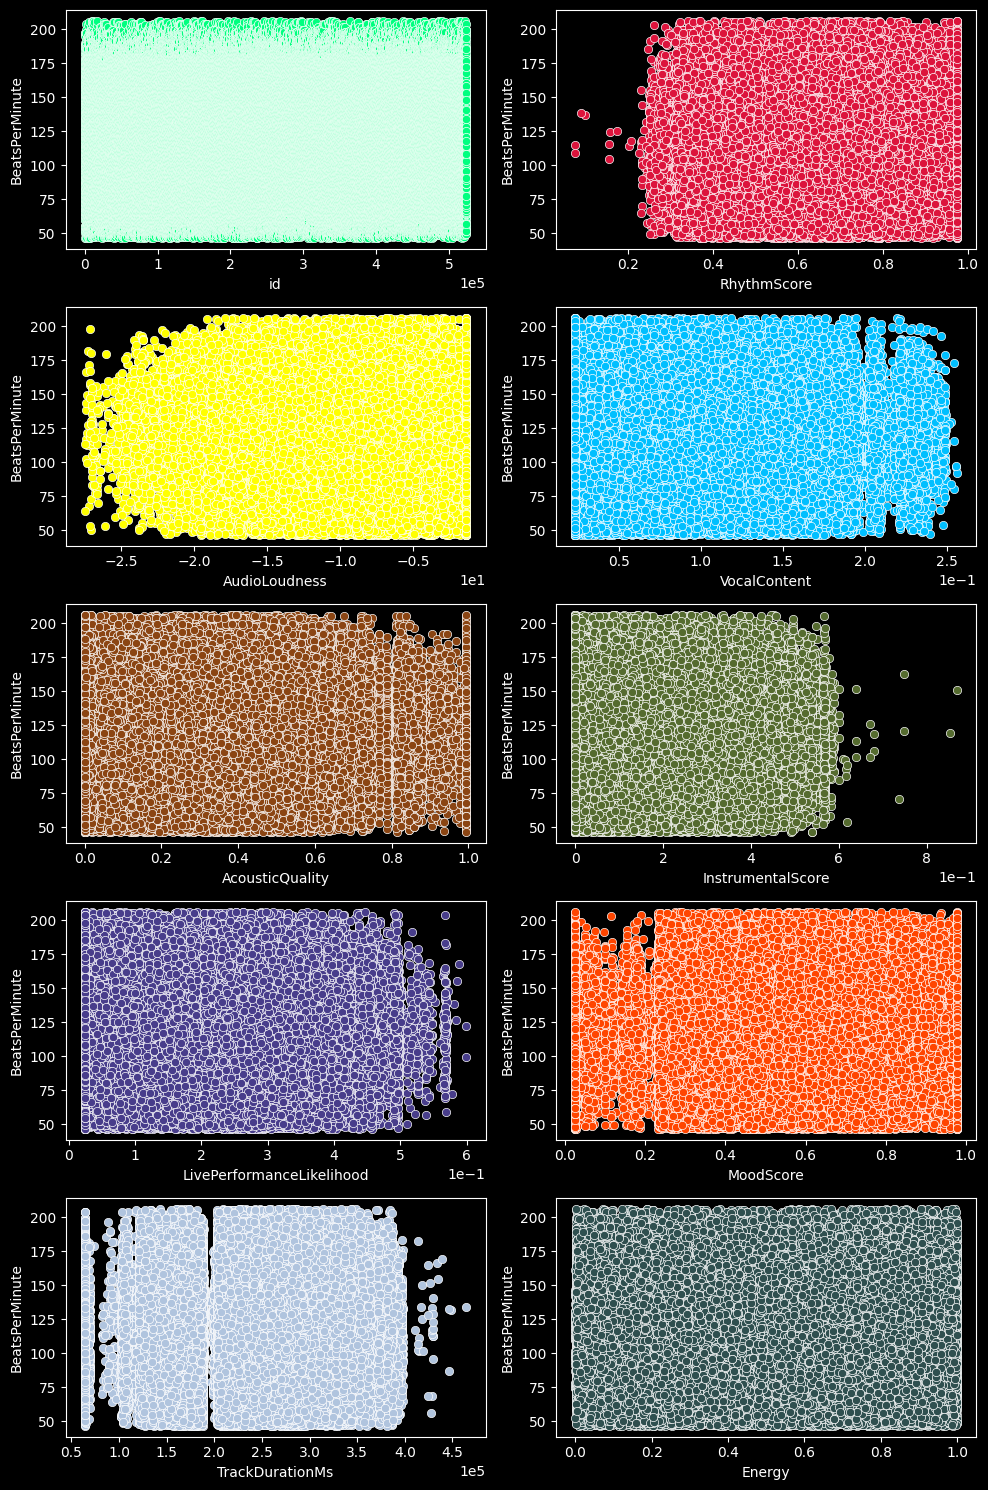

In [243]:
plt.style.use('dark_background')

figure = plt.figure(figsize = (10, 15))

number_of_rows = 5
number_of_cols = 2
colors = ['#00FF7F', '#DC143C', '#FFFF00', '#00BFFF', '#8B4513', '#556B2F', '#483D8B', '#FF4500', '#B0C4DE', '#2F4F4F']

grid_spec = GridSpec(nrows = number_of_rows, ncols = number_of_cols, figure = figure)

for index, feature in enumerate(features):
  axes = figure.add_subplot(grid_spec[(index) // (number_of_cols), (index % number_of_cols)])
  sns.scatterplot(data = df_train, x = feature, y = 'BeatsPerMinute', color = colors[index], ax = axes)
  axes.ticklabel_format(style = 'scientific', axis = 'x', scilimits = (0, 0))

plt.tight_layout()
plt.show()

- We see that we don't have any horizontal bars since the **BeatsPerMinute** distribution is normal.
- **RhythmScore** has a vertical bar up to $0.2$, meaning basically all values are greater than $0.2$.
- The points in the **id**, **AcousticQuality**, **MoodScore**, and **Energy** graphs are evenly distributed throughout the rectangle.
- **AudioLoudness** has sparsity of data on the left side.
- The data points **VocalContent**, **InstrumentalScore**, **LivePerformanceLikelihood**, **TrackDurationMs** are highly sparse in the right part of the rectangle.
- **TrackDurationMs** also has vertical bars in the range from $0.5*10^5$ to $1.0*10^5$. And a band of $2.0 * 10^5$.

## 🔬 **4. Data preparation**

In [244]:
X = df_train.drop(columns = ['BeatsPerMinute'])

In [245]:
y = df_train['BeatsPerMinute']

In [246]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True)

In [247]:
dtrain = xgb.DMatrix(X_train, y_train)
dtest = xgb.DMatrix(X_test, y_test)

## 🏋 **5. Model training**

In [248]:
params = {'objective': 'reg:squarederror',
          'learning_rate': 0.1,
          'tree_method': 'hist'}

In [249]:
evals = [(dtrain, 'train'), (dtest, 'test')]

In [250]:
evals_result = {}

In [251]:
model = xgb.train(
    params = params,
    dtrain = dtrain,
    num_boost_round = 100,
    early_stopping_rounds = 10,
    evals = evals,
    verbose_eval = 1,
    evals_result = evals_result
)

[0]	train-rmse:26.44814	test-rmse:26.52849
[1]	train-rmse:26.44425	test-rmse:26.52688
[2]	train-rmse:26.44077	test-rmse:26.52613
[3]	train-rmse:26.43743	test-rmse:26.52550
[4]	train-rmse:26.43450	test-rmse:26.52538
[5]	train-rmse:26.43161	test-rmse:26.52458
[6]	train-rmse:26.42878	test-rmse:26.52414
[7]	train-rmse:26.42624	test-rmse:26.52376
[8]	train-rmse:26.42377	test-rmse:26.52369
[9]	train-rmse:26.42143	test-rmse:26.52349
[10]	train-rmse:26.41891	test-rmse:26.52325
[11]	train-rmse:26.41631	test-rmse:26.52313
[12]	train-rmse:26.41385	test-rmse:26.52312
[13]	train-rmse:26.41188	test-rmse:26.52290
[14]	train-rmse:26.40937	test-rmse:26.52242
[15]	train-rmse:26.40637	test-rmse:26.52272
[16]	train-rmse:26.40373	test-rmse:26.52254
[17]	train-rmse:26.40132	test-rmse:26.52258
[18]	train-rmse:26.39859	test-rmse:26.52265
[19]	train-rmse:26.39580	test-rmse:26.52235
[20]	train-rmse:26.39351	test-rmse:26.52237
[21]	train-rmse:26.39157	test-rmse:26.52246
[22]	train-rmse:26.38886	test-rmse:26.5229

## 🧾 **6. Cross-Validation of the model**

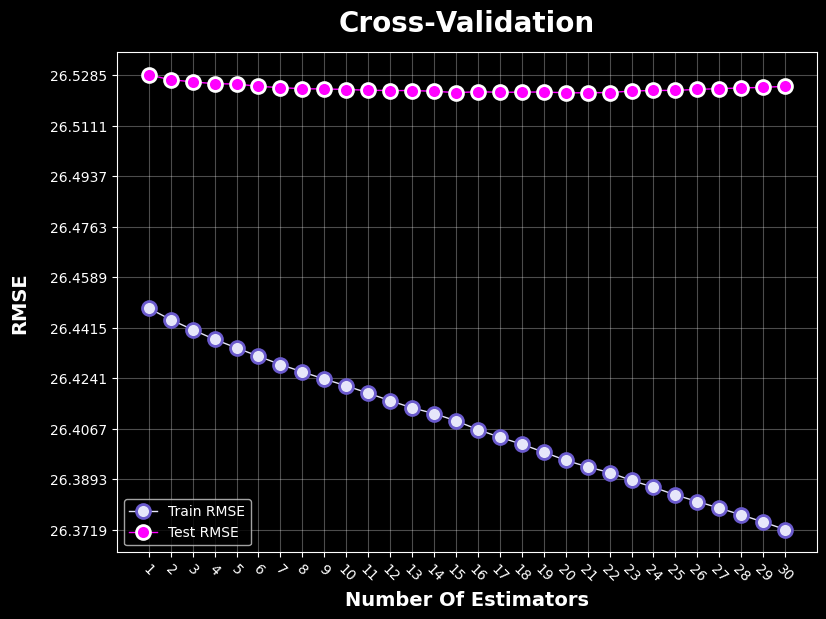

In [252]:
plt.style.use('dark_background')

figure = plt.figure(figsize = (7, 5))

train_rmse_result = evals_result['train']['rmse']
test_rmse_result = evals_result['test']['rmse']

xticks = np.arange(len(train_rmse_result))
yticks = np.linspace(min(train_rmse_result + test_rmse_result), max(train_rmse_result + test_rmse_result), 10)

axes = figure.add_axes([0, 0, 1, 1])
axes.plot(train_rmse_result, marker = 'o', linestyle = '-', linewidth = 1, color = '#E6E6FA',
          markeredgecolor = '#6A5ACD', markersize = 10, markeredgewidth = 2, label = 'Train RMSE'
          )
axes.plot(test_rmse_result, marker = 'o', linestyle = '-', linewidth = 1, color = '#FF00FF',
          markeredgecolor = '#FFFFFF', markersize = 10, markeredgewidth = 2, label = 'Test RMSE'
          )
axes.set_xlabel('Number Of Estimators', fontweight = 'bold', fontsize = 14)
axes.set_ylabel('RMSE', fontweight = 'bold', labelpad = 15, fontsize = 14)
axes.set_title('Cross‑Validation', fontweight = 'bold', pad = 15, fontsize = 20)
axes.xaxis.set_ticks(xticks)
axes.yaxis.set_ticks(yticks)
axes.xaxis.set_ticklabels([str(tick + 1) for tick in axes.get_xticks()], rotation = -45)
axes.grid(alpha = 0.3)

plt.legend()
plt.show()

- The **RMSE** on the training data should be less than on the test data, because the model gets used to the data it was trained on.

## 🍀 **7. Model evaluation**

In [253]:
prediction = model.predict(dtest)

In [254]:
print(f'MSE = {mean_squared_error(y_test, prediction):.3f}')

MSE = 703.554


In [255]:
print(f'MAPE = {mean_absolute_percentage_error(y_test, prediction):.3f}')

MAPE = 0.199


In [256]:
print(f'R2 = {r2_score(y_test, prediction):.6f}')


R2 = 0.000408


## 📊 **8. Displaying important features**

In [257]:
feature_weights = pd.Series(model.get_score(importance_type = 'weight')).sort_values()

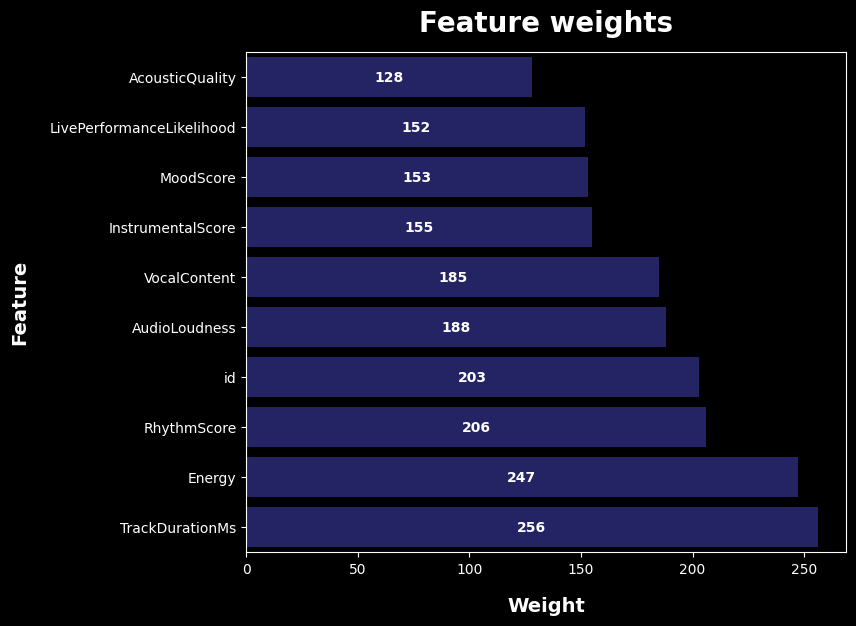

In [258]:
plt.style.use('dark_background')

figure = plt.figure(figsize = (6, 5))

axes = figure.add_axes([0, 0, 1, 1])
sns.barplot(feature_weights, errorbar = None, color = '#191970', orient = 'y', ax = axes)
axes.bar_label(axes.containers[0], label_type = 'center', fontweight = 'bold', fontsize = 10)
axes.set_xlabel('Weight', fontweight = 'bold', labelpad = 15, fontsize = 14)
axes.set_ylabel('Feature', fontweight = 'bold', labelpad = 15, fontsize = 14)
axes.set_title('Feature weights', fontweight = 'bold', pad = 15, fontsize = 20)

plt.show()

- We see that the most important parameter by which the model is built is **TrackDurationMs**, and the most useless is **AcousticQuality**.

## 🦸🏻‍♂️ **9. Saving predictions**

In [259]:
dtest = xgb.DMatrix(df_test)

In [260]:
submission = pd.DataFrame({'id': df_test['id'], 'BeatsPerMinute': model.predict(dtest)})

In [261]:
submission.to_csv('submission.csv', index = False)